In [26]:
import numpy as np
import pandas as pd
import os
%pip install osmnx networkx

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import json
import osmnx as ox
import matplotlib.patches as mpatches

In [5]:
G=ox.graph_from_place("Udupi, Karnataka, India",network_type="drive")
ox.save_graphml(G,"udupi_graph.graphml")

In [6]:
class Counter:
    count = 0
    def __init__(self):
        Counter.count += 1

In [7]:
graph={}
def snap_node_to_graph(lat, lon, G):
  i=Counter().count
  node = ox.distance.nearest_nodes(G,lon,lat,return_dist=False)
  graph[i]={"graph_node": node}
  return node

In [8]:
simulation_nodes = [
    {"id": 1, "name": "MIT Manipal", "lat": 13.3520, "lon": 74.7929},
    {"id": 2, "name": "KMC Manipal", "lat": 13.3443, "lon": 74.7901},
    {"id": 3, "name": "End Point", "lat": 13.3460, "lon": 74.7840},
    {"id": 4, "name": "Udupi Krishna Temple", "lat": 13.3410, "lon": 74.7420},
    {"id": 5, "name": "Udupi Bus Stand", "lat": 13.3389, "lon": 74.7461},
    {"id": 6, "name": "Malpe Beach", "lat": 13.3497, "lon": 74.7012},
    {"id": 7, "name": "Kaup Beach", "lat": 13.1967, "lon": 74.7453},
    {"id": 8, "name": "Katapady", "lat": 13.3173, "lon": 74.7800},
    {"id": 9, "name": "Parkala", "lat": 13.3315, "lon": 74.8012},
    {"id": 10, "name": "Perampalli", "lat": 13.3575, "lon": 74.7680}
]

In [9]:
nodes={}
for i in range(1,11):
  nodes[i]={"node_id":snap_node_to_graph(simulation_nodes[i-1]["lat"],simulation_nodes[i-1]["lon"],G)}
nodes

{1: {'node_id': 9573044997},
 2: {'node_id': 13310635421},
 3: {'node_id': 1828385039},
 4: {'node_id': 10738332287},
 5: {'node_id': 7577263725},
 6: {'node_id': 7537744939},
 7: {'node_id': 2549599794},
 8: {'node_id': 7509319874},
 9: {'node_id': 6673290438},
 10: {'node_id': 7518540381}}

In [10]:
nods, EDGES = ox.graph_to_gdfs(G)

In [11]:
EDGES

osmid       highway  \
u           v           key                                                     
276334151   7552299136  0                             413059545  unclassified   
            2061058764  0                [44771056, 1379367916]         trunk   
459837766   459838713   0                             809481460         trunk   
            1465683075  0                             805245460   residential   
459837910   2639847430  0    [809481459, 809481460, 1370367943]         trunk   
...                                                         ...           ...   
12851419991 11242950407 0                            1213515984   residential   
            12851419989 0                            1388295288         trunk   
13455816859 11259946402 0                            1215345596      tertiary   
            11259946426 0                            1215345596      tertiary   
            11259946409 0                            1215345598   residential   

                             oneway reversed      length   lanes maxspeed  \
u           v           key                                                 
276334151   7552299136  0     False    False   52.420486     NaN      NaN   
            2061058764  0      True    False  225.843856  [2, 3]       80   
459837766   459838713   0      True    False   57.410032       2      100   
            1465683075  0     False     True  343.624835     NaN      NaN   
459837910   2639847430  0      True    False  685.790533       2      100   
...                             ...      ...         ...     ...      ...   
12851419991 11242950407 0     False     True   78.757259     NaN      NaN   
            12851419989 0      True    False  111.714296       2      NaN   
13455816859 11259946402 0     False     True   21.773196     NaN      NaN   
            11259946426 0     False    False  152.782013     NaN      NaN   
            11259946409 0     False     True  227.622602     NaN      NaN   

                               ref  \
u           v           key          
276334151   7552299136  0      NaN   
            2061058764  0     NH66   
459837766   459838713   0     NH66   
            1465683075  0      NaN   
459837910   2639847430  0     NH66   
...                            ...   
12851419991 11242950407 0      NaN   
            12851419989 0    NH169   
13455816859 11259946402 0      NaN   
            11259946426 0      NaN   
            11259946409 0      NaN   

                                                                      geometry  \
u           v           key                                                      
276334151   7552299136  0     LINESTRING (74.7745 13.12392, 74.77497 13.12402)   
            2061058764  0    LINESTRING (74.7745 13.12392, 74.77456 13.1230...   
459837766   459838713   0     LINESTRING (74.74363 13.36226, 74.7438 13.36275)   
            1465683075  0    LINESTRING (74.74363 13.36226, 74.74336 13.362...   
459837910   2639847430  0    LINESTRING (74.73788 13.35161, 74.73815 13.352...   
...                                                                        ...   
12851419991 11242950407 0      LINESTRING (74.9964 13.18654, 74.99713 13.1865)   
            12851419989 0    LINESTRING (74.9964 13.18654, 74.99634 13.1861...   
13455816859 11259946402 0    LINESTRING (74.94853 13.18221, 74.94844 13.18238)   
            11259946426 0    LINESTRING (74.94853 13.18221, 74.94876 13.181...   
            11259946409 0    LINESTRING (74.94853 13.18221, 74.94864 13.182...   

                            bridge name access junction width tunnel  
u           v           key                                           
276334151   7552299136  0      NaN  NaN    NaN      NaN   NaN    NaN  
            2061058764  0      NaN  NaN    NaN      NaN   NaN    NaN  
459837766   459838713   0      NaN  NaN    NaN      NaN   NaN    NaN  
            1465683075  0      NaN  NaN    NaN      NaN   NaN    NaN  
459837910   26

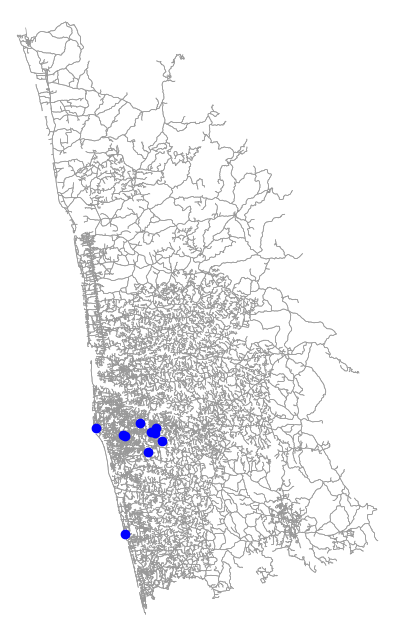

In [ ]:
def plot_nodes_by_id(G, node_ids):
    fig, ax = ox.plot_graph(G, show=False, close=False, bgcolor='white', node_size=0, edge_linewidth=0.5, edge_color='#999999')
    x_coords = []
    y_coords = []
    for nid in node_ids:
        x_coords.append(G.nodes[nid]['x'])
        y_coords.append(G.nodes[nid]['y'])

    # Plot all the collected node coordinates on the same axes
    plt.scatter(x_coords, y_coords, c='blue')
    plt.show()
plot_nodes_by_id(G, [val['graph_node'] for val in graph.values()])

In [ ]:
graph

{1: {'graph_node': 9573044997},
 2: {'graph_node': 13310635421},
 3: {'graph_node': 1828385039},
 4: {'graph_node': 10738332287},
 5: {'graph_node': 7577263725},
 6: {'graph_node': 7537744939},
 7: {'graph_node': 2549599794},
 8: {'graph_node': 7509319874},
 9: {'graph_node': 6673290438},
 10: {'graph_node': 7518540381}}

In [21]:
init_edges = {}
def apply_closure(G, edge_u, edge_v):
    if G.has_edge(edge_u, edge_v):
        for key in G[edge_u][edge_v]:
            length = EDGES.loc[(edge_u,edge_v)]["length"].values[0]
            if (edge_u, edge_v) not in init_edges:
                init_edges[(edge_u, edge_v)] = length
            G[edge_u][edge_v][key]['length'] = 99999999
    else:
        G.add_edge(edge_u, edge_v, length=99999999)

In [15]:
def lift_closure(G, edge_u, edge_v):
    if (edge_u, edge_v) in init_edges:
        original_length = init_edges[(edge_u, edge_v)]
        if G.has_edge(edge_u, edge_v):
            for key in G[edge_u][edge_v]:
                G[edge_u][edge_v][key]['length'] = original_length
        else:
            G.add_edge(edge_u, edge_v, length=original_length)

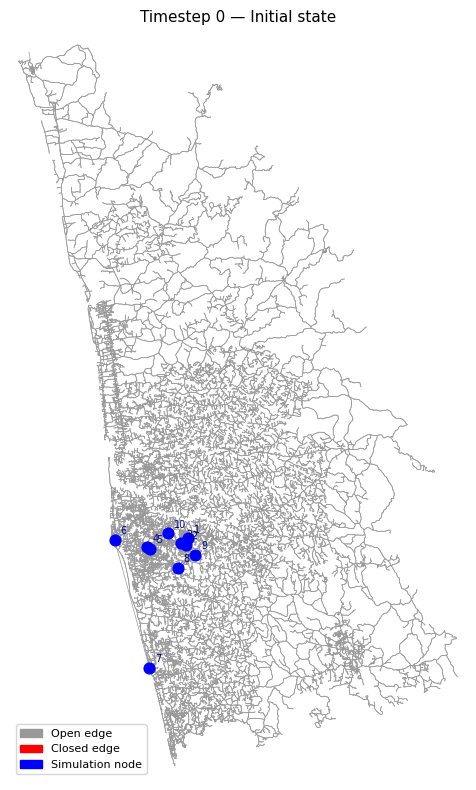

In [25]:
def plot_sim(G, node_ids, closed_edges=None, timestep=None, event_desc=None):
    if closed_edges is None:
        closed_edges = set()

    fig, ax = ox.plot_graph(
        G, show=False, close=False,
        bgcolor='white', node_size=0,
        edge_linewidth=0.5, edge_color='#999999'
    )

    for (u, v) in closed_edges:
        if G.has_node(u) and G.has_node(v):
            x = [G.nodes[u]['x'], G.nodes[v]['x']]
            y = [G.nodes[u]['y'], G.nodes[v]['y']]
            ax.plot(x, y, color='red', linewidth=2.5, zorder=3)

    x_coords = [G.nodes[nid]['x'] for nid in node_ids]
    y_coords = [G.nodes[nid]['y'] for nid in node_ids]
    ax.scatter(x_coords, y_coords, c='blue', s=60, zorder=5)

    for i, nid in enumerate(node_ids):
        ax.annotate(
            str(i + 1),
            (G.nodes[nid]['x'], G.nodes[nid]['y']),
            fontsize=7, color='darkblue', zorder=6,
            xytext=(4, 4), textcoords='offset points'
        )

    open_patch   = mpatches.Patch(color='#999999', label='Open edge')
    closed_patch = mpatches.Patch(color='red',     label='Closed edge')
    node_patch   = mpatches.Patch(color='blue',    label='Simulation node')
    ax.legend(handles=[open_patch, closed_patch, node_patch], loc='lower left', fontsize=8)

    title = f"Timestep {timestep}" if timestep is not None else "Road Graph"
    if event_desc:
        title += f" — {event_desc}"
    ax.set_title(title, fontsize=11)

    plt.tight_layout()
    plt.show()

plot_sim(G, [val['graph_node'] for val in graph.values()], timestep=0, event_desc="Initial state")

In [17]:
import time

for current_timestep in range(1, 30):
    with open("/content/closures.json") as f:
        data = json.load(f)

    for event in data["events"]:
        if event["timestep"] != current_timestep:
            continue
        u = event["u"]
        v = event["v"]
        action = event["action"]

        if action == "close":
            apply_closure(G, u, v)
        elif action == "lifted":
            lift_closure(G, u, v)

    edg = []
    for u, v, d in G.edges(data=True):
        edg.append({"u": u, "v": v, "length": d["length"]})

    with open("/content/current_graph.json", "w") as f:
        json.dump({"edges": edg}, f)

    time.sleep(1)

In [18]:
apply_closure(G, 13310635421, 1828385039)
print(G[13310635421][1828385039])  # should show length: 99999999

lift_closure(G, 13310635421, 1828385039)
print(G[13310635421][1828385039])  # should restore original length

{0: {'length': 99999999}}
{0: {'length': np.float64(227.62260152260532)}}


/tmp/ipykernel_1731/2381486361.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  length = EDGES.loc[(u, v)]["length"].values[0]


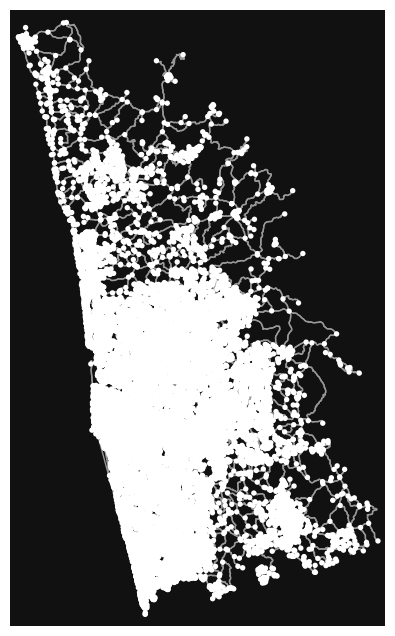

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [20]:
ox.plot_graph(G)